In [2]:
#Task 1 )— Load Data into bank_df, Preview & info()

import pandas as pd

bank_df = pd.read_csv("bank-full.csv")

# Display first 10 rows
bank_df.head(10)

# Display DataFrame information
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


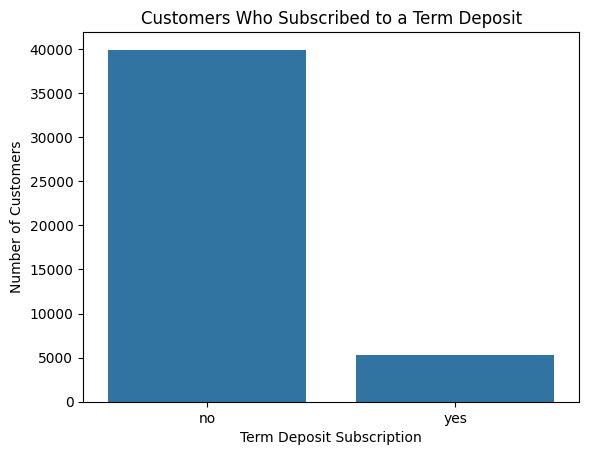

In [3]:
#Task 2 )— Countplot: Term Deposit Subscription (y)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=bank_df, x='Target')

plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")
plt.title("Customers Who Subscribed to a Term Deposit")

plt.show()

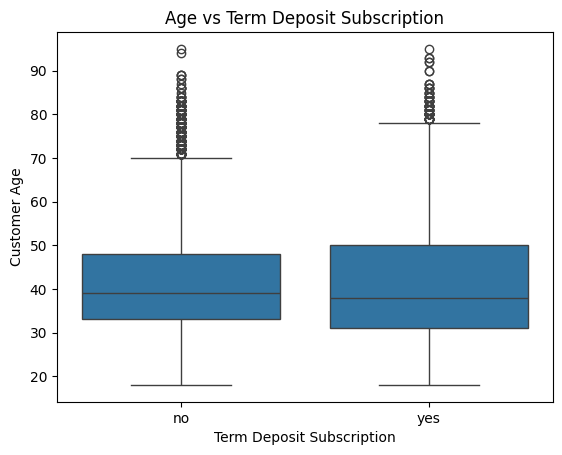

In [4]:
 #Task 3 — Boxplot: Age vs Subscription

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=bank_df, x='Target', y='age')

plt.xlabel("Term Deposit Subscription")
plt.ylabel("Customer Age")
plt.title("Age vs Term Deposit Subscription")

plt.show()

In [ ]:
# Obervation :The boxplot shows that customers who subscribed to a term deposit (yes) tend to have a slightly higher median age than those who did not subscribe (no). The yes group also shows a wider age distribution, indicating that customers from different age groups subscribed. Overall, age appears to have some relationship with term-deposit subscription, with older customers showing a somewhat higher likelihood of subscribing.

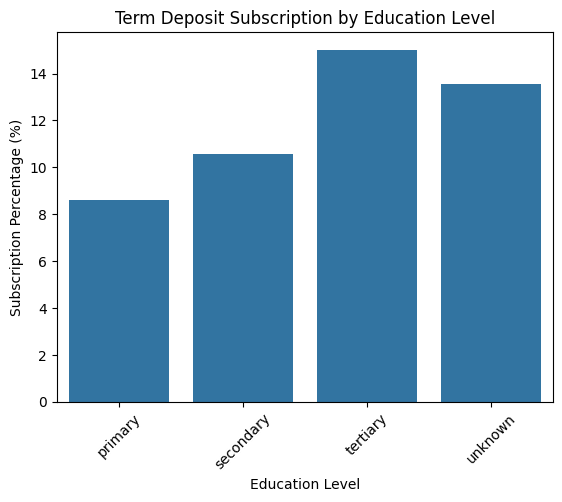

In [5]:
#Task 4 — Subscription Percentage by Education Level

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate subscription percentage by education
education_pct = (
    bank_df.groupby('education')['Target']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .reset_index(name='subscription_percentage')
)

# Create bar plot
sns.barplot(
    data=education_pct,
    x='education',
    y='subscription_percentage'
)

plt.xlabel("Education Level")
plt.ylabel("Subscription Percentage (%)")
plt.title("Term Deposit Subscription by Education Level")
plt.xticks(rotation=45)

plt.show()

In [6]:
#Task 5 — Two AI-Suggested Visualizations for a Fintech (Cred-style) Use Case
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate subscription rate by job
job_subscription = (
    bank_df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

# Sort by subscription rate
job_subscription = job_subscription.sort_values(
    "subscription_rate",
    ascending=False
)

# Seaborn style
sns.set_theme(style="whitegrid", palette="deep")

# Create barplot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=job_subscription,
    x="job",
    y="subscription_rate"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

KeyError: 'Column not found: y'

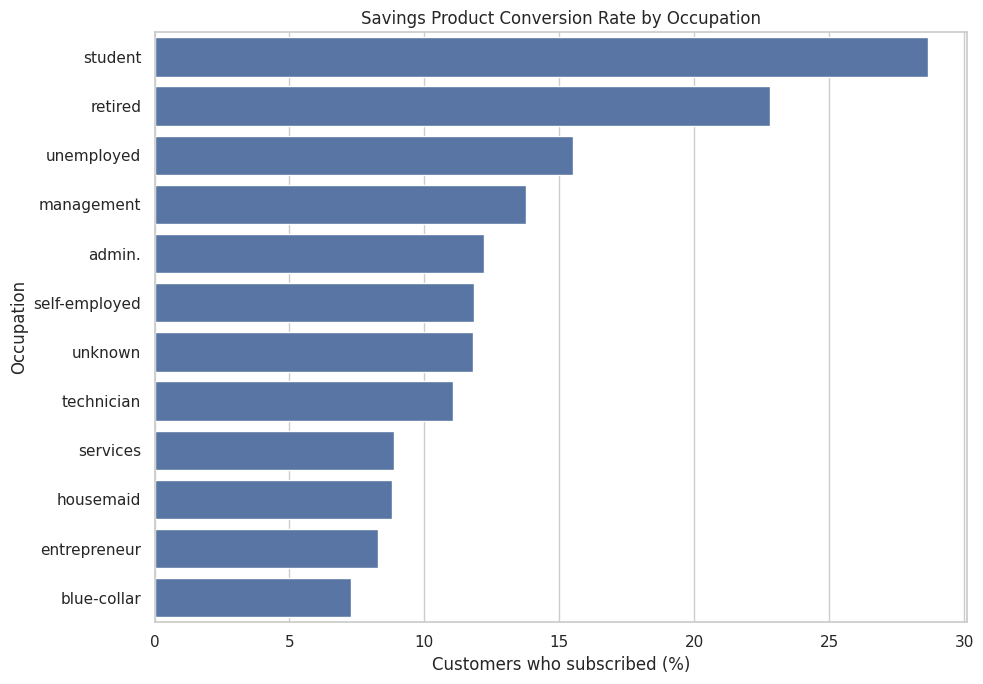

In [9]:
#Task 5 — Two AI-Suggested Visualizations for a Fintech (Cred-style) Use Case
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("bank-full.csv")

# Calculate subscription/conversion rate by occupation
job_summary = (
    df.groupby("job")["Target"]
      .agg(
          conversion_rate=lambda x: (x == "yes").mean() * 100,
          customers="size"
      )
      .query("customers >= 100")  # Ignore very small groups
      .sort_values("conversion_rate", ascending=False)
      .reset_index()
)

# Create visualization
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

sns.barplot(
    data=job_summary,
    x="conversion_rate",
    y="job"
)

plt.title("Savings Product Conversion Rate by Occupation")
plt.xlabel("Customers who subscribed (%)")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

In [ ]:
# obervation: This visualization helps identify which job categories have higher term-deposit subscription rates. A fintech company like Cred can use this insight to identify customer segments that may be more interested in a new savings product